# Cas pratique : Construire un CNN simple avec PyTorch + Data Augmentation

## Objectif

Construire et entraîner un CNN amélioré pour CIFAR-10 avec :

- augmentation des données ;
- normalisation automatique du jeu d'entraînement ;
- Batch Normalization ;
- Dropout ;
- AdamW ;
- Label Smoothing ;
- CosineAnnealingLR ;
- Early Stopping ;
- sauvegarde du meilleur modèle ;
- évaluation finale sur le test set.

> Cette version est une évolution de la version précédente qui obtenait environ **86,58 %** de Test Accuracy.


## 1. Importer les bibliothèques

Nous utilisons PyTorch et TorchVision pour construire le CNN, charger CIFAR-10 et appliquer les transformations.


In [1]:
import copy
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms


## 2. Reproductibilité et choix du device

Sur Mac Apple Silicon, PyTorch peut utiliser **MPS** lorsque celui-ci est disponible. Sinon, on utilise CUDA ou CPU.


In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Device utilisé :", device)


Device utilisé : mps


## 3. Calculer automatiquement mean et std

Nous ne choisissons pas manuellement les statistiques de normalisation.

On calcule `mean` et `std` directement à partir du dataset CIFAR-10 d'entraînement, **sans augmentation aléatoire**.

La formule utilisée est :

`x_normalized = (x - mean) / std`


In [3]:
# Dataset temporaire uniquement pour calculer mean/std
stats_transform = transforms.ToTensor()

stats_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=stats_transform
)

loader_stats = DataLoader(
    stats_dataset,
    batch_size=512,
    shuffle=False,
    num_workers=0
)

mean = torch.zeros(3)
std = torch.zeros(3)
total_images = 0

for images, _ in loader_stats:
    batch_size = images.size(0)

    # Moyenne par canal
    mean += images.mean(dim=(0, 2, 3)) * batch_size

    # E[x²] par canal
    std += (images ** 2).mean(dim=(0, 2, 3)) * batch_size

    total_images += batch_size

mean /= total_images
std = torch.sqrt(std / total_images - mean ** 2)

print("Mean automatique :", mean)
print("Std automatique  :", std)


Mean automatique : tensor([0.4914, 0.4822, 0.4465])
Std automatique  : tensor([0.2470, 0.2435, 0.2616])


## 4. Définir les transformations

### Entraînement

Nous utilisons :

1. `RandomCrop(32, padding=4)` ;
2. `RandomHorizontalFlip` ;
3. conversion en tenseur ;
4. normalisation automatique ;
5. `RandomErasing`.

`RandomErasing` est appliqué après `ToTensor` et `Normalize`, car il travaille sur une image Tensor.

### Validation/Test

Aucune transformation aléatoire n'est utilisée. Cela permet d'évaluer le modèle sur les images originales.


In [4]:
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(p=0.5),

    transforms.ToTensor(),
    transforms.Normalize(mean.tolist(), std.tolist()),

    transforms.RandomErasing(
        p=0.25,
        scale=(0.02, 0.15),
        ratio=(0.3, 3.3)
    )
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean.tolist(), std.tolist())
])


## 5. Charger CIFAR-10

CIFAR-10 contient 10 classes :

`airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck`.

Nous séparons les 50 000 images d'entraînement en :

- 45 000 images pour l'entraînement ;
- 5 000 images pour la validation.

Les 10 000 images officielles du test restent complètement séparées.


In [5]:
full_train_aug = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)

full_train_eval = datasets.CIFAR10(
    root="./data",
    train=True,
    download=False,
    transform=eval_transform
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=eval_transform
)

train_size = 45000
val_size = 5000

generator = torch.Generator().manual_seed(SEED)

train_indices, val_indices = random_split(
    range(len(full_train_aug)),
    [train_size, val_size],
    generator=generator
)

train_indices = train_indices.indices
val_indices = val_indices.indices

# Même split pour les deux versions du dataset
train_dataset = torch.utils.data.Subset(full_train_aug, train_indices)
val_dataset = torch.utils.data.Subset(full_train_eval, val_indices)

print("Train :", len(train_dataset))
print("Validation :", len(val_dataset))
print("Test :", len(test_dataset))


Train : 45000
Validation : 5000
Test : 10000


## 6. DataLoaders

Nous choisissons un batch size de 64.

`shuffle=True` est utilisé uniquement pour le train.


In [6]:
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

images, labels = next(iter(train_loader))

print("Images :", images.shape)
print("Labels :", labels.shape)


Images : torch.Size([64, 3, 32, 32])
Labels : torch.Size([64])


['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


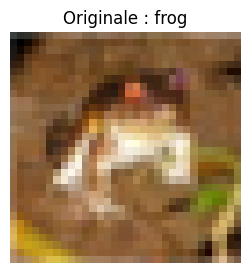

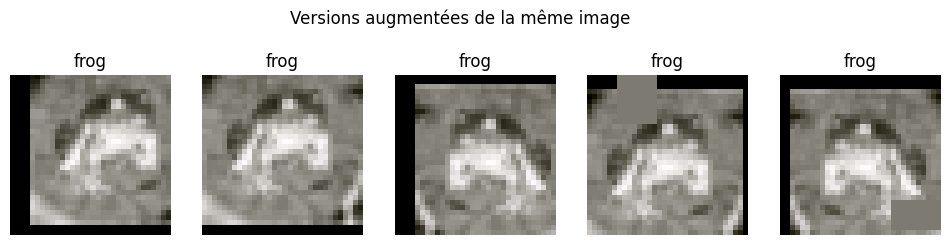

In [8]:
classes = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]
print(classes)

def unnormalize(img):
    mean_t = mean.to(device=img.device, dtype=img.dtype).view(3, 1, 1)
    std_t = std.to(device=img.device, dtype=img.dtype).view(3, 1, 1)
    return (img * std_t + mean_t).clamp(0, 1)

raw_base = datasets.CIFAR10(
    root='./data', train=True, download=False, transform=transforms.ToTensor()
)
raw_img, label = raw_base[0]

plt.figure(figsize=(3, 3))
plt.imshow(raw_img.permute(1, 2, 0))
plt.title(f'Originale : {classes[label]}')
plt.axis('off')
plt.show()

fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for ax in axes:
    img, lab = full_train_aug[0]  # nouvelle augmentation à chaque accès
    ax.imshow(unnormalize(img[0]).permute(1, 2, 0))
    ax.set_title(classes[lab])
    ax.axis('off')
plt.suptitle('Versions augmentées de la même image')
plt.show()

## 7. Construire un CNN plus puissant

Par rapport à la version précédente, nous augmentons la capacité :

`3 → 64 → 128 → 256`

Chaque bloc contient deux convolutions, BatchNorm et ReLU.

Après trois MaxPooling, la taille spatiale devient :

`32 × 32 → 16 × 16 → 8 × 8 → 4 × 4`

Enfin, `AdaptiveAvgPool2d(1)` transforme les cartes de caractéristiques en un vecteur compact de 256 valeurs.


In [7]:
class ImprovedCNN(nn.Module):

    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2),
            nn.Dropout(0.20),

            # Block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2),
            nn.Dropout(0.30),

            # Block 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2),
            nn.Dropout(0.40)
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),

            nn.Linear(256, 128),
            nn.ReLU(inplace=True),

            nn.Dropout(0.40),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = ImprovedCNN(num_classes=10).to(device)

print(model)


ImprovedCNN(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.2, inplace=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (12): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): MaxP

## 8. Vérifier les dimensions

Le modèle doit transformer :

`[B, 3, 32, 32]`

en :

`[B, 10]`.


In [9]:
with torch.no_grad():
    dummy = torch.zeros(2, 3, 32, 32, device=device)
    output = model(dummy)

print("Entrée :", dummy.shape)
print("Sortie :", output.shape)

assert output.shape == (2, 10)


Entrée : torch.Size([2, 3, 32, 32])
Sortie : torch.Size([2, 10])


## 9. Compter les paramètres

Un modèle plus complexe n'est pas automatiquement meilleur. Nous vérifions donc combien de paramètres sont entraînables.


In [10]:
total_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Nombre de paramètres entraînables : {total_params:,}")


Nombre de paramètres entraînables : 1,180,490


## 10. Loss : CrossEntropy + Label Smoothing

`CrossEntropyLoss` est adaptée à la classification multi-classes.

Le `label_smoothing=0.1` évite que le réseau devienne excessivement confiant dans ses prédictions et peut améliorer la généralisation.


In [11]:
criterion = nn.CrossEntropyLoss(
    label_smoothing=0.1
)


## 11. Optimiseur AdamW

Nous utilisons AdamW avec :

- learning rate = `0.001`
- weight decay = `1e-4`

Le weight decay ajoute une régularisation des poids.


In [12]:
optimizer = optim.AdamW(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)


## 12. CosineAnnealingLR

Le learning rate diminue progressivement selon une courbe cosinus.

Nous commençons à `0.001` et descendons jusqu'à `1e-6`.


In [13]:
EPOCHS = 100

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS,
    eta_min=1e-6
)


## 13. Fonction d'entraînement

Pour chaque batch :

1. envoyer les images sur le device ;
2. remettre les gradients à zéro ;
3. forward propagation ;
4. calcul de la loss ;
5. backward propagation ;
6. mise à jour des poids.


In [14]:
def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item() * labels.size(0)

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = total_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


## 14. Fonction d'évaluation

Pendant la validation :

- `model.eval()` désactive le comportement d'entraînement de Dropout ;
- `torch.no_grad()` évite de calculer les gradients.


In [15]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):

    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        total_loss += loss.item() * labels.size(0)

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = total_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


## 15. Entraînement avec Early Stopping

Nous surveillons la validation loss.

Le meilleur modèle est sauvegardé en mémoire.

`PATIENCE = 12` signifie que nous autorisons plusieurs époques sans amélioration avant d'arrêter.


In [ ]:
PATIENCE = 12
MIN_DELTA = 1e-4

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "lr": []
}

best_val_loss = float("inf")
best_state = None
epochs_without_improvement = 0

for epoch in range(1, EPOCHS + 1):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    # Mise à jour du learning rate
    scheduler.step()

    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["lr"].append(current_lr)

    # Sauvegarde du meilleur modèle
    if val_loss < best_val_loss - MIN_DELTA:

        best_val_loss = val_loss
        epochs_without_improvement = 0

        best_state = copy.deepcopy(model.state_dict())

    else:
        epochs_without_improvement += 1

    print(
        f"Epoch {epoch:03d}/{EPOCHS} | "
        f"Train Loss={train_loss:.4f} | "
        f"Train Acc={train_acc:.2%} | "
        f"Val Loss={val_loss:.4f} | "
        f"Val Acc={val_acc:.2%} | "
        f"LR={current_lr:.7f}"
    )

    if epochs_without_improvement >= PATIENCE:

        print(
            f"\nEarly stopping à l'époque {epoch}."
        )

        break

# Restaurer le meilleur état
if best_state is not None:
    model.load_state_dict(best_state)

print(
    f"\nMeilleur Val Loss : {best_val_loss:.4f}"
)


Epoch 001/100 | Train Loss=1.6770 | Train Acc=44.79% | Val Loss=1.5023 | Val Acc=55.46% | LR=0.0009998
Epoch 002/100 | Train Loss=1.4049 | Train Acc=59.91% | Val Loss=1.3836 | Val Acc=60.72% | LR=0.0009990
Epoch 003/100 | Train Loss=1.2947 | Train Acc=65.73% | Val Loss=1.1500 | Val Acc=71.70% | LR=0.0009978
Epoch 004/100 | Train Loss=1.2189 | Train Acc=69.46% | Val Loss=1.1012 | Val Acc=74.06% | LR=0.0009961
Epoch 005/100 | Train Loss=1.1535 | Train Acc=72.88% | Val Loss=1.0822 | Val Acc=75.10% | LR=0.0009939
Epoch 006/100 | Train Loss=1.1081 | Train Acc=75.14% | Val Loss=1.0136 | Val Acc=78.88% | LR=0.0009912
Epoch 007/100 | Train Loss=1.0747 | Train Acc=76.71% | Val Loss=1.0034 | Val Acc=79.46% | LR=0.0009880
Epoch 008/100 | Train Loss=1.0438 | Train Acc=78.39% | Val Loss=0.9384 | Val Acc=83.02% | LR=0.0009843
Epoch 009/100 | Train Loss=1.0213 | Train Acc=79.38% | Val Loss=0.9223 | Val Acc=82.88% | LR=0.0009802
Epoch 010/100 | Train Loss=0.9983 | Train Acc=80.48% | Val Loss=0.9323 | 

## 16. Visualiser Loss et Accuracy

Une bonne courbe doit généralement montrer :

- train loss qui diminue ;
- validation loss qui diminue puis peut se stabiliser ;
- train accuracy qui augmente ;
- validation accuracy qui augmente puis se stabilise.

Une grande divergence entre train et validation peut signaler un overfitting.


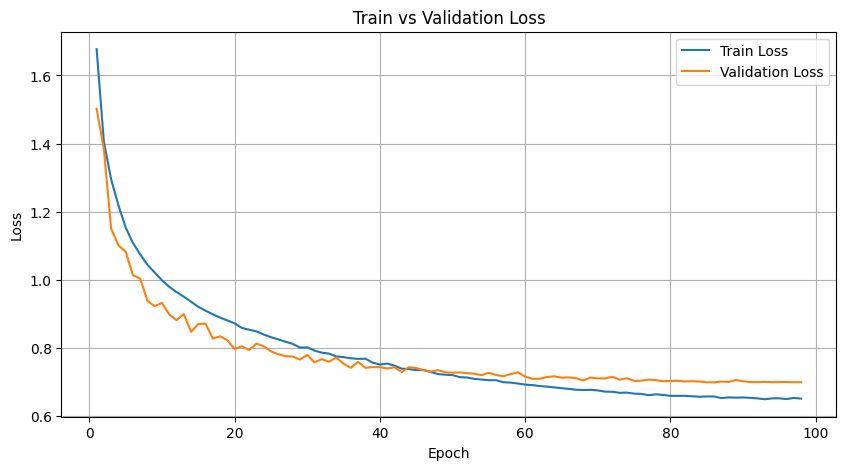

In [17]:
epochs_done = len(history["train_loss"])
epochs_range = range(1, epochs_done + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.grid()
plt.show()


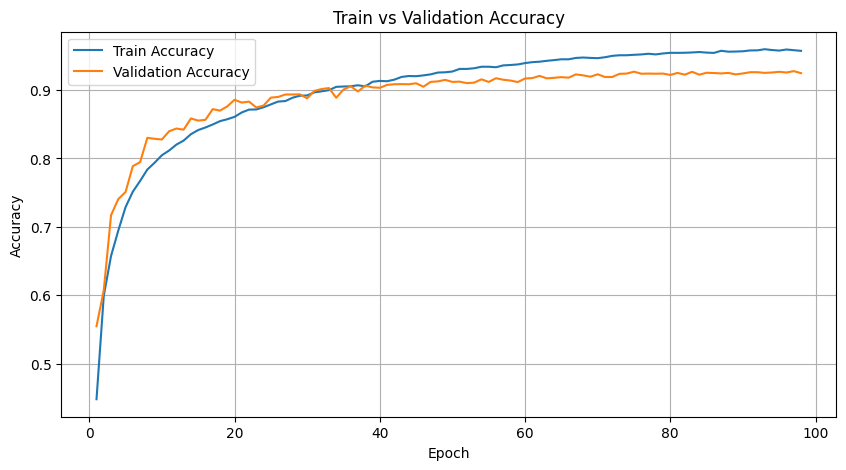

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(epochs_range, history["train_acc"], label="Train Accuracy")
plt.plot(epochs_range, history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs Validation Accuracy")
plt.legend()
plt.grid()
plt.show()


## 17. Visualiser l'évolution du Learning Rate


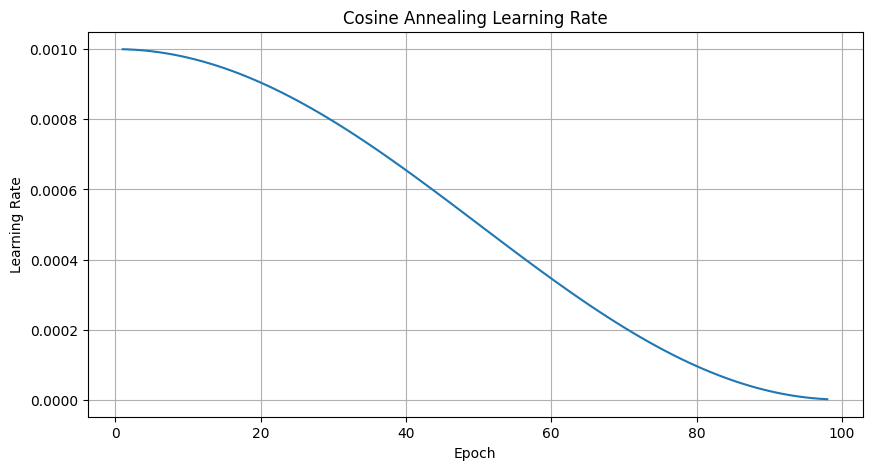

In [19]:
plt.figure(figsize=(10, 5))
plt.plot(epochs_range, history["lr"])
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Cosine Annealing Learning Rate")
plt.grid()
plt.show()


## 18. Évaluer le modèle sur le test set

Le test set est utilisé uniquement à la fin.

Il ne sert ni à entraîner le modèle ni à choisir les hyperparamètres.


In [20]:
test_loss, test_acc = evaluate(
    model,
    test_loader,
    criterion,
    device
)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.2%}")


Test Loss     : 0.7118
Test Accuracy : 92.00%


## 19. Comparaison avec la version précédente

La version précédente obtenait environ :

- Train Accuracy : 85,63 %
- Validation Accuracy maximale : 86,84 %
- Test Accuracy : 86,58 %

Cette version v3 est conçue pour tenter d'améliorer la généralisation avec :

- CNN plus large : 64 → 128 → 256 ;
- AdamW ;
- weight decay ;
- label smoothing ;
- cosine learning-rate schedule ;
- RandomErasing ;
- patience plus élevée.

**Important :** une amélioration n'est pas garantie. Il faut comparer les résultats expérimentaux avec le même split et la même seed.


## 20. Sauvegarder le meilleur modèle

On sauvegarde le modèle après l'entraînement.


In [21]:
# Create the model directory if it doesn't exist
import os

os.makedirs('./model', exist_ok=True)


MODEL_PATH = "./model/cnn_cifar10_pytorch_augmentation_V3.pth"

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "mean": mean,
        "std": std,
        "classes": train_dataset.dataset.classes
    },
    MODEL_PATH
)

print(f"Modèle sauvegardé : {MODEL_PATH}")


Modèle sauvegardé : ./model/cnn_cifar10_pytorch_augmentation_V3.pth


## 21. Charger le modèle sauvegardé

Exemple de restauration du meilleur modèle.


In [22]:
checkpoint = torch.load(
    MODEL_PATH,
    map_location=device,
    weights_only=False
)

loaded_model = ImprovedCNN(num_classes=10).to(device)
loaded_model.load_state_dict(checkpoint["model_state_dict"])

loaded_model.eval()

print("Modèle chargé avec succès.")


Modèle chargé avec succès.


## 22. Afficher quelques prédictions

Nous affichons des images du test set avec la classe prédite et la vraie classe.


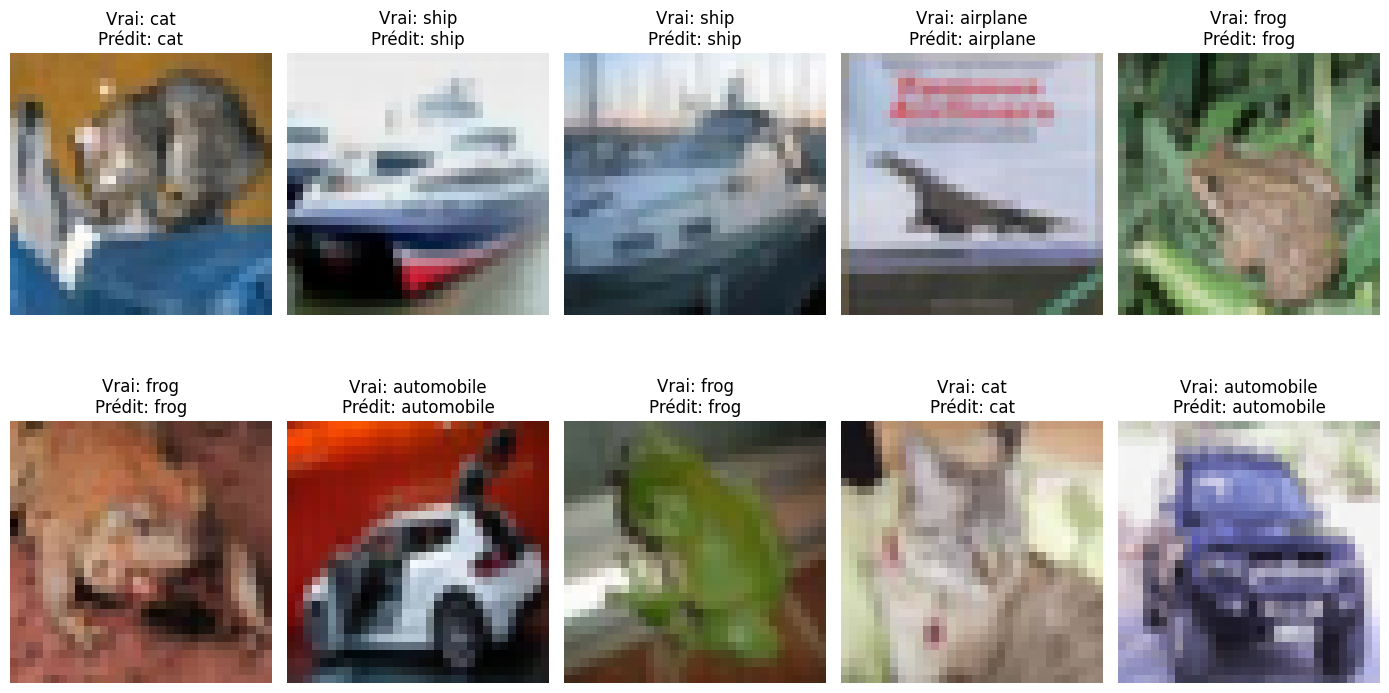

In [25]:
classes = test_dataset.classes

images, labels = next(iter(test_loader))

images_device = images.to(device)

with torch.no_grad():
    outputs = model(images_device)
    predictions = outputs.argmax(dim=1).cpu()

# Dé-normalisation pour affichage
mean_display = mean.view(1, 3, 1, 1)
std_display = std.view(1, 3, 1, 1)

images_display = images.cpu() * std_display + mean_display
images_display = images_display.clamp(0, 1)

fig, axes = plt.subplots(2, 5, figsize=(14, 8))

for i, ax in enumerate(axes.flat):

    image = images_display[i].permute(1, 2, 0)

    ax.imshow(image)

    true_label = classes[labels[i]]
    pred_label = classes[predictions[i]]

    ax.set_title(
        f"Vrai: {true_label}\nPrédit: {pred_label}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()


# Conclusion

## Pipeline final

```text
CIFAR-10
   ↓
45k Train / 5k Validation / 10k Test
   ↓
RandomCrop + HorizontalFlip
   ↓
ToTensor
   ↓
Normalization automatique
   ↓
RandomErasing
   ↓
CNN 64 → 128 → 256
   ↓
BatchNorm + ReLU + MaxPooling
   ↓
AdaptiveAvgPool
   ↓
Linear
   ↓
CrossEntropy + Label Smoothing
   ↓
AdamW
   ↓
CosineAnnealingLR
   ↓
Early Stopping
   ↓
Best Model
   ↓
Test Accuracy
```

### Points à retenir

- L'augmentation améliore surtout la généralisation, pas nécessairement le train accuracy.
- Validation et test doivent rester sans augmentation aléatoire.
- `AdamW` + `weight_decay` aide à contrôler l'overfitting.
- Le scheduler adapte progressivement le learning rate.
- `Label Smoothing` réduit les prédictions excessivement confiantes.
- Le meilleur modèle doit être choisi à partir de la validation, puis évalué une seule fois sur le test.


# Réaliser par : OUARAS Khelil Rafik